# Yield Curve Module 3: IRRBB -- OIS Curve Application

## 1. EBA IRRBB Stress Scenarios

Six prescribed rate shocks from EBA/GL/2022/14 applied to the ESTR OIS
discount curve bootstrapped in Notebook 2. The OIS curve is the regulatory
prescribed input for IRRBB EVE calculations under EBA/RTS/2022/09.

This notebook covers four components of the IRRBB framework:
1. EVE Supervisory Outlier Test -- six scenarios, 15% Tier 1 threshold
2. NII Supervisory Outlier Test -- parallel up/down, 5% Tier 1 threshold
3. Repricing gap -- cash flows bucketed into EBA maturity bands
4. SA vs full revaluation comparison

The six shock scenarios are:
- **Parallel up / down** -- uniform shift across all maturities
- **Steepener** -- short rates down, long rates up
- **Flattener** -- short rates up, long rates down
- **Short rate up / down** -- shock concentrated at the short end,
  fading linearly to zero at 20Y

#### EBA/RTS/2022/10 Annex I -- Prescribed IRRBB Shock Sizes (bps)

Source: EBA/RTS/2022/10, Annex I, October 2022.
These are regulatory inputs, not model calibrations.

 Currency | Parallel | Short | Long 
----------|----------|-------|------
 EUR      | 200      | 250   | 100  
 USD      | 200      | 300   | 150  
 JPY      | 100      | 100   | 100  
 BRL      | 400      | 500   | 300  
 GBP      | 250      | 300   | 150  
 CHF      | 100      | 150   | 100  

**EBA Methodology:** To arrive in these values, EBA calibrated schocks to the 99th percentile of rolling
6-month interest rate changes over 2000-2015. A floor of 100bps applies to
all currencies regardless of historical data. Caps are 400bps parallel,
500bps short, 300bps long.

**BRL note:** BRL is not an EBA-regulated currency -- it is included in the
Basel BCBS standard which uses the same methodology. A Luxembourg bank with
material BRL positions would apply these shocks under Pillar 2 ICAAP
at its own discretion, not as a mandatory EBA SOT.

**JPY note:** The 100bps flat shock across all tenors reflects the prolonged
near-zero rate environment in Japan. Post-2022 BoJ policy normalisation
has reopened debate on whether this remains appropriate -- the BCBS
recalibration exercise (d561, 2023) flagged this as a currency where
the current shocks may need upward revision.

**How the six scenarios are derived from these three shock sizes:**

Let $S_{parallel}$, $S_{short}$, $S_{long}$ denote the prescribed shock sizes
from the table above for a given currency. Then:

$$\Delta R_{parallel} = \pm S_{parallel}$$

$$\Delta R_{steepener} = -0.65 \cdot S_{short} + 0.9 \cdot S_{long}$$

$$\Delta R_{flattener} = +0.8 \cdot S_{short} - 0.6 \cdot S_{long}$$

$$\Delta R_{short\_up} = +S_{short} \text{ (fading linearly to zero at 20Y+)}$$

$$\Delta R_{short\_down} = -S_{short} \text{ (fading linearly to zero at 20Y+)}$$

#### Post-Shock Interest Rate Floor

EBA/RTS/2022/10 Article 4 imposes a maturity-dependent lower bound on
post-shock rates:

$$floor(T) = -150\text{bps} + 3\text{bps} \times T$$

The floor reflects the empirical lower bound on nominal interest rates --
the effective lower bound (ELB) below which monetary transmission breaks
down and cash hoarding becomes rational. It is not symmetric: only downward
shock scenarios can breach it, upward scenarios are unconstrained.

The slope of 3bps per year embeds the term premium -- longer maturities
can sustain slightly less negative rates because the compensation for
duration risk provides a natural floor. At key maturities:

| Maturity | Floor |
|----------|-------|
| 0Y       | -150bps |
| 10Y      | -120bps |
| 20Y      | -90bps  |
| 30Y      | -60bps  |

For EUR the floor is rarely binding post-2022 given the ECB has exited
negative rate territory and current short rates sit above 2%. For JPY
the floor is material -- with the BoJ only beginning normalisation in
2024, a -100bps parallel down shock on a curve starting near zero
immediately breaches the floor across the short and medium end.

The floor also has a practical implication for EVE: when the floor clips
a downward scenario, the actual EVE impact is smaller than the unclipped
version. The EBA requires institutions to report both the clipped
(regulatory) and unclipped (unconstrained) parallel down scenario
precisely to make this effect transparent to supervisors.

#### Data

OIS zero curve bootstrapped in Notebook 2, loaded from `data/processed/`.
All EVE calculations use OIS discounting as prescribed by EBA/RTS/2022/09.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

plt.style.use("seaborn-v0_8-whitegrid")

# -----------------------------------------------------------------------
# load OIS curve from data/processed
# -----------------------------------------------------------------------
project_root  = os.path.abspath(os.path.join(os.getcwd(), "../.."))
processed_dir = os.path.join(project_root, "data", "processed")

# find the most recent OIS curve file
ois_files = sorted([f for f in os.listdir(processed_dir) if f.startswith("ois_curve_")])
if not ois_files:
    raise FileNotFoundError("No OIS curve file found in data/processed. Run notebook 2 first.")

ois_file = os.path.join(processed_dir, ois_files[-1])
ois_data = pd.read_csv(ois_file, index_col="maturity")

valuation_date = ois_data["valuation_date"].iloc[0]
print(f"OIS curve loaded: {ois_file}")
print(f"Valuation date  : {valuation_date}")
print(f"\n{ois_data}")

OIS curve loaded: /Users/mrspatbile/Documents/coding/quant-risk-engine/data/processed/ois_curve_2026-03-24.csv
Valuation date  : 2026-03-24

              years  zero_rate_pct  discount_factor valuation_date
maturity                                                          
1M         0.083333       1.938381         0.998332     2026-03-24
2M         0.166667       1.951716         0.996644     2026-03-24
3M         0.250000       1.984957         0.994940     2026-03-24
6M         0.500000       2.062095         0.989516     2026-03-24
9M         0.750000       1.998665         0.984848     2026-03-24
12M        1.000000       2.023108         0.979697     2026-03-24
2Y         2.000000       2.154424         0.957196     2026-03-24
3Y         3.000000       2.208785         0.934851     2026-03-24
5Y         5.000000       2.331640         0.888460     2026-03-24
10Y       10.000000       2.624891         0.766168     2026-03-24
10Y+      15.000000       2.935061         0.639684    

In [ ]:
# EBA/RTS/2022/10 Annex I -- prescribed shock sizes in bps by currency
EBA_SHOCKS = {
    "EUR": {"parallel": 200, "short": 250, "long": 100},
    "USD": {"parallel": 200, "short": 300, "long": 150},
    "JPY": {"parallel": 100, "short": 100, "long": 100},
    "BRL": {"parallel": 400, "short": 500, "long": 300},
    "GBP": {"parallel": 250, "short": 300, "long": 150},
    "CHF": {"parallel": 100, "short": 150, "long": 100},
}

def compute_irrbb_scenarios(zero_rates, maturities, currency="EUR"):
    """
    Apply EBA/RTS/2022/10 six IRRBB shock scenarios to a zero rate curve.

    Shock sizes from Annex I. Steepener and flattener formulas from
    Table 1 of the RTS. Short rate shocks fade linearly to zero at 20Y.
    Post-shock floor applied per Article 4: -150bps + 3bps per year.

    Parameters
    ----------
    zero_rates : np.ndarray
        Baseline zero rates in percent.
    maturities : np.ndarray
        Corresponding maturities in years.
    currency : str
        One of EUR, USD, JPY, BRL, GBP, CHF.

    Returns
    -------
    dict of {scenario_name: shocked_zero_rates}
    """
    s = EBA_SHOCKS[currency]
    S_par   = s["parallel"] / 100
    S_short = s["short"]   / 100
    S_long  = s["long"]    / 100

    # weight for short/long interpolation: 0 at T=0, 1 at T=20Y
    w = np.clip(maturities / 20, 0, 1)

    # maturity-dependent shock profiles
    shock_parallel = S_par * np.ones_like(maturities)
    shock_short    = S_short * (1 - w)
    shock_long     = S_long  * w

    # post-shock floor: -150bps + 3bps per year, in percent
    floor = (-150 + 3 * maturities) / 100

    # six scenarios with floor applied
    raw = {
        "parallel_up"   :  zero_rates + shock_parallel,
        "parallel_down" :  zero_rates - shock_parallel,
        "steepener"     :  zero_rates - 0.65 * shock_short + 0.9 * shock_long,
        "flattener"     :  zero_rates + 0.8  * shock_short - 0.6 * shock_long,
        "short_up"      :  zero_rates + shock_short,
        "short_down"    :  zero_rates - shock_short,
    }

    # apply floor -- only downward scenarios can breach it
    scenarios = {
        name: np.maximum(curve, floor)
        for name, curve in raw.items()
    }

    return scenarios

# -----------------------------------------------------------------------
# build baseline from OIS curve loaded from data/processed
# -----------------------------------------------------------------------
T        = np.linspace(1/12, 30, 360)
baseline = np.interp(
    T,
    ois_data["years"].values,
    ois_data["zero_rate_pct"].values
)

scenarios = compute_irrbb_scenarios(baseline, T, currency="EUR")

# print short and long end for each scenario
print(f"Baseline curve: OIS -- valuation date {valuation_date}")
print(f"\n{'Scenario':<20} {'3M rate':>10} {'10Y rate':>10} {'30Y rate':>10}")
print("-" * 55)
print(f"{'Baseline':<20} {baseline[3]:>10.3f} {baseline[120]:>10.3f} {baseline[-1]:>10.3f}")
for name, curve in scenarios.items():
    print(f"{name:<20} {curve[3]:>10.3f} {curve[120]:>10.3f} {curve[-1]:>10.3f}")

Baseline curve: OIS -- valuation date 2026-03-24

Scenario                3M rate   10Y rate   30Y rate
-------------------------------------------------------
Baseline                  2.011      2.630      2.935
parallel_up               4.011      4.630      4.935
parallel_down             0.011      0.630      0.935
steepener                 0.428      2.278      3.835
flattener                 3.967      3.319      2.335
short_up                  4.469      3.870      2.935
short_down               -0.448      1.390      2.935


In [ ]:
# check if floor is binding for any EUR scenario
floor = (-150 + 3 * T) / 100

print("Floor binding check -- EUR scenarios:")
for name, curve in scenarios.items():
    n_clipped = np.sum(curve < floor + 1e-6)
    min_rate  = curve.min()
    if n_clipped > 0:
        print(f"  {name:<20} min rate: {min_rate:.3f}%   floor binding at {n_clipped} points")
    else:
        print(f"  {name:<20} min rate: {min_rate:.3f}%   floor not binding")

Floor binding check -- EUR scenarios:
  parallel_up          min rate: 4.033%   floor not binding
  parallel_down        min rate: 0.033%   floor not binding
  steepener            min rate: 0.419%   floor not binding
  flattener            min rate: 2.914%   floor not binding
  short_up             min rate: 3.514%   floor not binding
  short_down           min rate: -0.456%   floor not binding


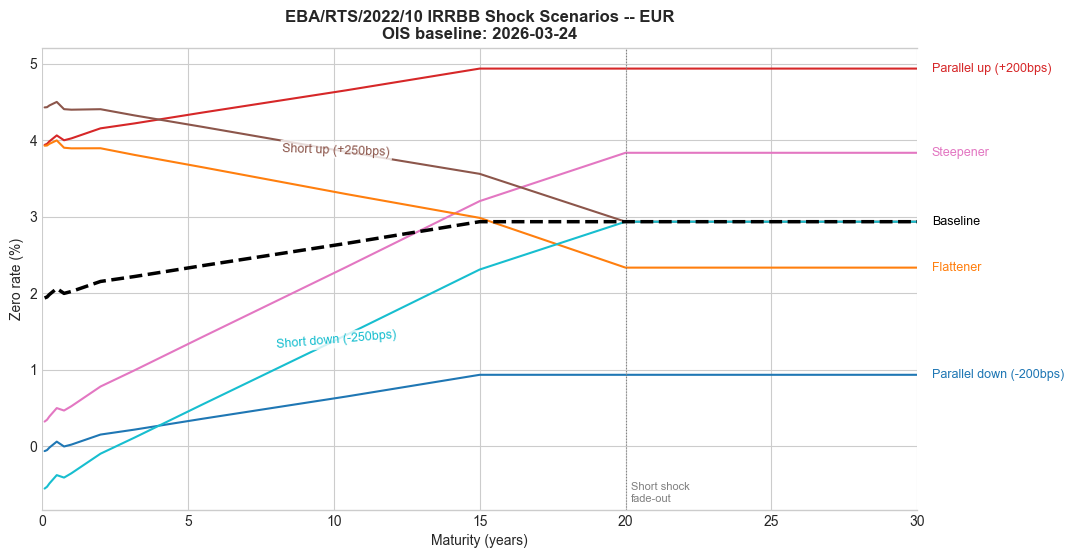

In [ ]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.set_xlim(0, 30)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)


colors = {
    "parallel_up"   : "#d62728",
    "parallel_down" : "#1f77b4",
    "steepener"     : "#e377c2",
    "flattener"     : "#ff7f0e",
    "short_up"      : "#8c564b",
    "short_down"    : "#17becf",
}

end_labels = {
    "parallel_up"   : ("Parallel up (+200bps)",  0.0),
    "parallel_down" : ("Parallel down (-200bps)", 0.0),
    "steepener"     : ("Steepener",               0.0),
    "flattener"     : ("Flattener",               0.0),
}

mid_labels = {
    "short_up"   : ("Short up (+250bps)",   120),
    "short_down" : ("Short down (-250bps)", 120),
}

def line_angle_correct(curve, ax):
    # data ranges
    x_data_range = ax.get_xlim()[1] - ax.get_xlim()[0]
    y_data_range = ax.get_ylim()[1] - ax.get_ylim()[0]
    
    # axis size in pixels
    bbox = ax.get_window_extent()
    x_pixel_range = bbox.width
    y_pixel_range = bbox.height
    
    # slope in data units
    x1, x2 = T[50], T[200]
    y1, y2 = curve[50], curve[200]
    data_slope = (y2 - y1) / (x2 - x1)
    
    # convert slope to display angle accounting for aspect ratio
    display_slope = data_slope * (x_pixel_range / x_data_range) / (y_pixel_range / y_data_range)
    
    return np.degrees(np.arctan(display_slope))

# baseline
ax.plot(T, baseline, color="black", linewidth=2.5, linestyle="--", zorder=5)
ax.text(30.5, baseline[-1], "Baseline", color="black", fontsize=9,
        va="center", clip_on=False)

# plot all scenarios
for name, curve in scenarios.items():
    ax.plot(T, curve, color=colors[name], linewidth=1.5)

    if name in end_labels:
        label, offset = end_labels[name]
        ax.text(30.5, curve[-1] + offset, label,
                color=colors[name], fontsize=9, va="center",
                clip_on=False)

# rendering plot before adding mid labels
# so text angle transforms are stable
fig.canvas.draw()

for name, (label, idx) in mid_labels.items():
    curve = scenarios[name]
    angle = line_angle_correct(curve, ax)
    ax.text(T[idx], curve[idx], label,
            color=colors[name], fontsize=9,
            va="center", ha="center",
            rotation=angle,
            rotation_mode="anchor",
            bbox=dict(facecolor="white", edgecolor="none",
                      alpha=0.8, pad=1.5))

# 20Y boundary
ax.axvline(x=20, color="grey", linewidth=0.8, linestyle=":")
ax.text(20.2, ax.get_ylim()[0] + 0.1, "Short shock\nfade-out",
        color="grey", fontsize=8)

ax.set_title(
    f"EBA/RTS/2022/10 IRRBB Shock Scenarios -- EUR\n"
    f"OIS baseline: {valuation_date}",
    fontsize=12, fontweight="bold"
)

ax.set_ylabel("Zero rate (%)")
ax.set_xlabel("Maturity (years)")

fig.subplots_adjust(right=0.75)

plt.show()

## 2. EVE Impact Table -- IRRBB Supervisory Outlier Test

Economic Value of Equity (EVE) is the present value of all asset cash flows
minus the present value of all liability cash flows:

$$EVE = PV(\text{assets}) - PV(\text{liabilities})$$

When rates shift, both sides reprice and the net change is $\Delta EVE$.
For a single cash flow of notional $N$ at maturity $T$:

$$\Delta EVE(s, T) = N \cdot \left[ P_s(0, T) - P_{base}(0, T) \right]$$

Where $P_s(0,T) = e^{-r_s(T) \cdot T / 100}$ uses the shocked zero rate.

The EBA supervisory outlier test (SOT) flags a bank as an outlier if:

$$\frac{|\Delta EVE|}{Tier 1 \, capital} > 15\%$$

$\Delta EVE$ is computed from the full balance sheet. Tier 1 capital enters
only as the normalisation reference -- the loss-absorbing buffer against
which the interest rate risk is sized. A bank with EUR 1bn Tier 1 capital
breaches the SOT if any scenario produces $|\Delta EVE|$ exceeding EUR 150M.

**Key properties:**

- $\Delta EVE$ scales linearly with notional -- results below are per EUR 1M
- $\Delta EVE$ is larger in absolute terms for longer maturities -- duration effect
- The post-shock floor clips downward scenarios, reducing $|\Delta EVE|$ for
  parallel down and short down at short maturities
- A bank with a structural long position in fixed rate assets will show
  negative $\Delta EVE$ under parallel up -- the classic banking book mismatch
  the IRRBB framework is designed to capture

<center>

SOT threshold: $\dfrac{|\Delta EVE|}{Tier 1} > 15\%$ triggers supervisory action

</center>

Baseline discount curve: ESTR OIS bootstrapped in Notebook 2, loaded
from `data/processed/`. Shocked discount factors are derived by applying
the EBA shocks to the OIS zero rates and recomputing $P_s(0,T) = e^{-r_s(T) \cdot T/100}$.

In [ ]:
# EVE impact table -- per EUR 1M notional at each pillar maturity
# Delta EVE = N * (P_shocked - P_baseline)

N = 1_000_000  # EUR 1M notional

records = []
for label, row_data in ois_data.iterrows():
    T_i    = row_data["years"]
    r_base = row_data["zero_rate_pct"]
    df_base = np.exp(-r_base / 100 * T_i)

    row = {
        "maturity"    : label,
        "zero_rate_%"  : round(r_base, 4),
        "df_baseline"  : round(df_base, 6),
    }

    # delta EVE under each scenario
    for name, curve in scenarios.items():
        r_shocked  = np.interp(T_i, T, curve)
        df_shocked = np.exp(-r_shocked / 100 * T_i)
        delta_eve  = (df_shocked - df_base) * N
        row[name]  = round(delta_eve, 2)

    records.append(row)

eve_table = pd.DataFrame(records).set_index("maturity")

print(f"Delta EVE per EUR 1M notional -- OIS baseline {valuation_date}\n")
print(eve_table.to_string())

Delta EVE per EUR 1M notional -- 2026-04-16

          zero_rate_%  df_baseline    parallel_up  parallel_down     steepener     flattener      short_up   short_down
maturity                                                                                                               
3M           2.147500     0.994646   -4960.820000    4985.680000   3970.170000  -4880.400000  -6119.920000  6157.810000
6M           2.270400     0.988712   -9837.850000    9936.720000   7751.450000  -9519.660000 -11976.800000 12123.660000
1Y           2.404700     0.976240  -19330.840000   19721.350000  14741.590000 -18086.050000 -22912.530000 23463.220000
2Y           2.488600     0.951447  -37306.760000   38829.280000  26478.980000 -32540.860000 -41866.060000 43793.060000
3Y           2.527500     0.926979  -53983.030000   57321.150000  35313.440000 -43708.990000 -57250.630000 61019.200000
5Y           2.656800     0.875607  -83324.990000   92088.350000  44605.700000 -57152.840000 -78357.720000 86059.12

## 1. EBA IRRBB Stress Scenarios

Six prescribed rate shocks from EBA/GL/2022/14. Applied to today's NSS curve
to compute the shocked zero rate at each pillar maturity and the resulting
change in Economic Value of Equity (EVE) per EUR 1M notional.

The six scenarios are:
- **Parallel up / down** -- uniform shift across all maturities
- **Steepener** -- short rates down, long rates up
- **Flattener** -- short rates up, long rates down
- **Short rate up / down** -- shock concentrated at the short end, fading toward zero at long maturities

#### EBA/RTS/2022/10 Annex I -- Prescribed IRRBB Shock Sizes (bps)

Source: EBA/RTS/2022/10, Annex I, October 2022.
These are regulatory inputs, not model calibrations.

 Currency | Parallel | Short | Long 
----------|----------|-------|------
 EUR      | 200      | 250   | 100  
 USD      | 200      | 300   | 150  
 JPY      | 100      | 100   | 100  
 BRL      | 400      | 500   | 300  
 GBP      | 250      | 300   | 150  
 CHF      | 100      | 150   | 100  

**EBA Methodology:** To arrive in these values, EBA calibrated schocks to the 99th percentile of rolling
6-month interest rate changes over 2000-2015. A floor of 100bps applies to
all currencies regardless of historical data. Caps are 400bps parallel,
500bps short, 300bps long.

**BRL note:** BRL is not an EBA-regulated currency -- it is included in the
Basel BCBS standard which uses the same methodology. A Luxembourg bank with
material BRL positions would apply these shocks under Pillar 2 ICAAP
at its own discretion, not as a mandatory EBA SOT.

**JPY note:** The 100bps flat shock across all tenors reflects the prolonged
near-zero rate environment in Japan. Post-2022 BoJ policy normalisation
has reopened debate on whether this remains appropriate -- the BCBS
recalibration exercise (d561, 2023) flagged this as a currency where
the current shocks may need upward revision.

**How the six scenarios are derived from these three shock sizes:**

Let $S_{parallel}$, $S_{short}$, $S_{long}$ denote the prescribed shock sizes
from the table above for a given currency. Then:

$$\Delta R_{parallel} = \pm S_{parallel}$$

$$\Delta R_{steepener} = -0.65 \cdot S_{short} + 0.9 \cdot S_{long}$$

$$\Delta R_{flattener} = +0.8 \cdot S_{short} - 0.6 \cdot S_{long}$$

$$\Delta R_{short\_up} = +S_{short} \text{ (fading linearly to zero at 20Y+)}$$

$$\Delta R_{short\_down} = -S_{short} \text{ (fading linearly to zero at 20Y+)}$$

#### Post-Shock Interest Rate Floor

EBA/RTS/2022/10 Article 4 imposes a maturity-dependent lower bound on
post-shock rates:

$$floor(T) = -150\text{bps} + 3\text{bps} \times T$$

The floor reflects the empirical lower bound on nominal interest rates --
the effective lower bound (ELB) below which monetary transmission breaks
down and cash hoarding becomes rational. It is not symmetric: only downward
shock scenarios can breach it, upward scenarios are unconstrained.

The slope of 3bps per year embeds the term premium -- longer maturities
can sustain slightly less negative rates because the compensation for
duration risk provides a natural floor. At key maturities:

| Maturity | Floor |
|----------|-------|
| 0Y       | -150bps |
| 10Y      | -120bps |
| 20Y      | -90bps  |
| 30Y      | -60bps  |

For EUR the floor is rarely binding post-2022 given the ECB has exited
negative rate territory and current short rates sit above 2%. For JPY
the floor is material -- with the BoJ only beginning normalisation in
2024, a -100bps parallel down shock on a curve starting near zero
immediately breaches the floor across the short and medium end.

The floor also has a practical implication for EVE: when the floor clips
a downward scenario, the actual EVE impact is smaller than the unclipped
version. The EBA requires institutions to report both the clipped
(regulatory) and unclipped (unconstrained) parallel down scenario
precisely to make this effect transparent to supervisors.

In [ ]:
# color negative values red, positive green
def color_delta(val):
    if isinstance(val, float):
        color = "#d62728" if val < 0 else "#2ca02c"
        return f"color: {color}"
    return ""

tbl = eve_table.drop(columns=["df_baseline"]).style\
    .format({
        "zero_rate_%"   : "{:.4f}%",
        "parallel_up"   : "{:,.0f}",
        "parallel_down" : "{:,.0f}",
        "steepener"     : "{:,.0f}",
        "flattener"     : "{:,.0f}",
        "short_up"      : "{:,.0f}",
        "short_down"    : "{:,.0f}",
    })

tbl.map(color_delta, subset=[
        "parallel_up", "parallel_down",
        "steepener", "flattener",
        "short_up", "short_down"
    ])\
    .set_caption(
        f"ΔEVE per EUR 1M notional -- EBA/RTS/2022/10 scenarios -- {params.index[-1]}"
    )


,zero_rate_%,parallel_up,parallel_down,steepener,flattener,short_up,short_down
maturity,,,,,,,
3M,2.1475%,"-4,961","4,986","3,970","-4,880","-6,120","6,158"
6M,2.2704%,"-9,838","9,937","7,751","-9,520","-11,977","12,124"
1Y,2.4047%,"-19,331","19,721","14,742","-18,086","-22,913","23,463"
2Y,2.4886%,"-37,307","38,829","26,479","-32,541","-41,866","43,793"
3Y,2.5275%,"-53,983","57,321","35,313","-43,709","-57,251","61,019"
5Y,2.6568%,"-83,325","92,088","44,606","-57,153","-78,358","86,059"
7Y,2.8287%,"-107,174","123,279","43,690","-60,265","-88,205","98,831"
10Y,3.0746%,"-133,289","162,800","27,144","-49,712","-86,401","97,906"
15Y,3.3655%,"-156,446","211,180","-23,849","-4,510","-54,017","59,326"


In [ ]:
# alternative with gradinet coloring based on magnitude of impact
# find the largest absolute value across all scenario columns
tbl.background_gradient(
        subset=scenario_cols,
        cmap="RdYlGn",
        vmin=-max_abs,
        vmax=max_abs
    )\
    .set_caption(
        f"ΔEVE per EUR 1M notional -- EBA/RTS/2022/10 scenarios -- {params.index[-1]}"
    )

,zero_rate_%,parallel_up,parallel_down,steepener,flattener,short_up,short_down
maturity,,,,,,,
3M,2.1475%,"-4,961","4,986","3,970","-4,880","-6,120","6,158"
6M,2.2704%,"-9,838","9,937","7,751","-9,520","-11,977","12,124"
1Y,2.4047%,"-19,331","19,721","14,742","-18,086","-22,913","23,463"
2Y,2.4886%,"-37,307","38,829","26,479","-32,541","-41,866","43,793"
3Y,2.5275%,"-53,983","57,321","35,313","-43,709","-57,251","61,019"
5Y,2.6568%,"-83,325","92,088","44,606","-57,153","-78,358","86,059"
7Y,2.8287%,"-107,174","123,279","43,690","-60,265","-88,205","98,831"
10Y,3.0746%,"-133,289","162,800","27,144","-49,712","-86,401","97,906"
15Y,3.3655%,"-156,446","211,180","-23,849","-4,510","-54,017","59,326"


## 3. NII Supervisory Outlier Test

Net Interest Income (NII) measures the difference between interest earned
on assets and interest paid on liabilities over a defined horizon -- here
one year, as prescribed by EBA/RTS/2022/10.

$$NII = \sum_i r_i^{assets} \cdot N_i^{assets} - \sum_j r_j^{liabilities} \cdot N_j^{liabilities}$$

The NII SOT flags an outlier if:

$$\frac{|\Delta NII|}{Tier 1 \, capital} > 5\%$$

Where $\Delta NII = NII_{shocked} - NII_{baseline}$ under parallel up or
parallel down scenarios over a one-year horizon.

Only two scenarios apply to the NII SOT -- parallel up and parallel down.
The other four scenarios (steepener, flattener, short up, short down) are
EVE-only.

**Stylised banking book for illustration:**

A simplified balance sheet used to demonstrate the NII calculation.
In a production system the cash flow engine provides actual contractual
and behavioural cash flows per instrument.

| Position | Type | Notional (EUR M) | Rate | Maturity |
|----------|------|-----------------|------|----------|
| Bond portfolio | Fixed rate asset | 500 | NSS AAA 5Y | 5Y |
| Loan book | Fixed rate asset | 300 | NSS AAA 3Y + 150bps credit spread | 3Y |
| Wholesale deposits | Floating liability | 600 | ESTR | Overnight |
| Retail deposits (NMD) | Floating liability | 200 | ESTR - 50bps | Modelled 2Y |

Tier 1 capital assumed: EUR 150M (illustrative).

The bond and loan rates are fixed at inception -- they do not reprice
when rates move. The deposit liabilities reprice immediately (wholesale)
or with a behavioural lag (retail NMDs modelled as 2Y average repricing).

In [ ]:
# -----------------------------------------------------------------------
# stylised banking book
# -----------------------------------------------------------------------

# load NSS AAA curve for asset rates
nss_aaa_files = sorted([f for f in os.listdir(processed_dir) 
                         if f.startswith("nss_aaa_curve_")])
nss_aaa_file  = os.path.join(processed_dir, nss_aaa_files[-1])
nss_aaa_data  = pd.read_csv(nss_aaa_file, index_col="maturity")

# get NSS AAA rates at key maturities
r_aaa_3y = nss_aaa_data.loc["3Y", "zero_rate_pct"]
r_aaa_5y = nss_aaa_data.loc["5Y", "zero_rate_pct"]
r_ois_on  = ois_data.loc["1M", "zero_rate_pct"]  # proxy for overnight

print(f"NSS AAA 3Y rate : {r_aaa_3y:.4f}%")
print(f"NSS AAA 5Y rate : {r_aaa_5y:.4f}%")
print(f"OIS overnight   : {r_ois_on:.4f}%")

# banking book positions
credit_spread = 1.50  # 150bps on loan book
nmd_spread    = -0.50 # retail deposits pay ESTR - 50bps

book = {
    "bond_portfolio" : {
        "type"     : "asset",
        "notional" : 500,       # EUR M
        "rate"     : r_aaa_5y,  # fixed, NSS AAA 5Y
        "maturity" : 5.0,
        "repricing": "fixed",
    },
    "loan_book" : {
        "type"     : "asset",
        "notional" : 300,
        "rate"     : r_aaa_3y + credit_spread,
        "maturity" : 3.0,
        "repricing": "fixed",
    },
    "wholesale_deposits" : {
        "type"     : "liability",
        "notional" : 600,
        "rate"     : r_ois_on,  # floating -- reprices immediately
        "maturity" : 0.0,       # overnight
        "repricing": "floating",
    },
    "retail_nmd" : {
        "type"     : "liability",
        "notional" : 200,
        "rate"     : max(0, r_ois_on + nmd_spread),
        "maturity" : 2.0,       # behavioural average repricing
        "repricing": "floating",
    },
}

tier1_capital = 150  # EUR M illustrative

print(f"\nTier 1 capital  : EUR {tier1_capital}M")
print(f"\nBanking book:")
print(f"{'Position':<25} {'Type':<12} {'Notional':>12} {'Rate':>8} {'Maturity':>10} {'Repricing':>10}")
print("-" * 82)
for name, pos in book.items():
    print(f"{name:<25} {pos['type']:<12} {pos['notional']:>10}M "
          f"{pos['rate']:>7.4f}% {pos['maturity']:>9.1f}Y "
          f"{pos['repricing']:>10}")

# -----------------------------------------------------------------------
# baseline NII -- one year horizon
# -----------------------------------------------------------------------
def compute_nii(book, rate_shock_pct=0.0):
    """
    Compute annual NII for the stylised banking book.
    Fixed rate positions keep their rate.
    Floating rate positions reprice by rate_shock_pct.
    """
    nii = 0.0
    for name, pos in book.items():
        if pos["repricing"] == "fixed":
            rate = pos["rate"]
        else:
            rate = max(0, pos["rate"] + rate_shock_pct)

        interest = pos["notional"] * rate / 100

        if pos["type"] == "asset":
            nii += interest
        else:
            nii -= interest

    return nii

# baseline and shocked NII
nii_base = compute_nii(book, rate_shock_pct=0.0)

# parallel up and down shocks in percent
shock_up   = EBA_SHOCKS["EUR"]["parallel"] / 100
shock_down = -EBA_SHOCKS["EUR"]["parallel"] / 100

nii_up   = compute_nii(book, rate_shock_pct=shock_up)
nii_down = compute_nii(book, rate_shock_pct=shock_down)

delta_nii_up   = nii_up   - nii_base
delta_nii_down = nii_down - nii_base

sot_up   = abs(delta_nii_up)   / tier1_capital * 100
sot_down = abs(delta_nii_down) / tier1_capital * 100

print(f"\nNII SOT -- one year horizon")
print(f"{'':30} {'Baseline':>12} {'Parallel up':>13} {'Parallel down':>15}")
print("-" * 72)
print(f"{'NII (EUR M)':30} {nii_base:>12.2f} {nii_up:>13.2f} {nii_down:>15.2f}")
print(f"{'Delta NII (EUR M)':30} {'--':>12} {delta_nii_up:>13.2f} {delta_nii_down:>15.2f}")
print(f"{'Delta NII / Tier 1 (%)':30} {'--':>12} {sot_up:>13.2f} {sot_down:>15.2f}")
print(f"{'SOT breach (>5%)':30} {'--':>12} {'YES' if sot_up > 5 else 'NO':>13} {'YES' if sot_down > 5 else 'NO':>15}")